In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib as mpl
import tensorflow.random as tf_r
import keras_tuner
import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten #, Reshape
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras import Input
from scipy.optimize import curve_fit
from tensorflow.keras import layers
from tensorflow.keras.regularizers import L1L2

plt.rcParams['font.size'] = 14

np.random.seed(12345)
tf_r.set_seed(12345)

2026-05-14 16:00:42.454241: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-14 16:00:42.466090: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-14 16:00:42.985837: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-14 16:00:45.675915: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

In [9]:
np.random.seed(12345)

jump = lambda drift1, drift2, std1, std2: [int(np.random.normal(drift1,std1)), int(np.random.normal(drift2, std2))]

def pattern(i,z1,z2,a1,a2):
    return [int(a1*np.sin((np.pi*i)/z1)), int(a2*np.sin((np.pi*i)/z2))]

In [10]:
def build_model(L, l, r, n_class=3, kernel_size=11, NF=5, stddev=0.05):
    
    input_shape = (L, 2)

    if r == 2:
        reg = tf.keras.regularizers.l2(l)
    elif r == 1:
        reg = tf.keras.regularizers.l1(l)
    elif r == 0:
        l2 = np.abs(1-l)
        reg = L1L2(l, l2)
        
    
    ini = tf.keras.initializers.RandomNormal(mean=0.0, stddev=stddev, seed=None)
    
        
    model = Sequential([
        Conv1D(filters=NF, kernel_size=kernel_size,
               kernel_initializer=ini,
               kernel_regularizer=reg,
               padding='same',
               activation='relu',
               input_shape=input_shape),
        MaxPooling1D(pool_size=2), #we need to catch a signal that is above the noise
        Conv1D(filters=NF * 2, kernel_size=5, activation='relu'),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(n_class, activation='softmax')
    ])
    
    model.compile(
        loss=keras.losses.categorical_crossentropy,
        optimizer=tf.keras.optimizers.Adam(),
        metrics=['accuracy']
    )
    
    return model

In [19]:


SNRs = [0.1, 0.3, 1, 3, 10, 30]

# training set size and time series
N=10000
L=60
n_class = 3
# noise bias 
bias = 5 

#duration of the pattern
d = 11 # kernel size
Z1 = Z2 = d

# since i want to test the effectiveness of SNR as a measure classifiability 
# i start by seeing if different training sets (different amplitude and time)
# but with same SNR give more or less the same result: similar accuracy after
# a fixed number of epochs
pattern_params = []
sigma = 20

for SNR in SNRs:
    SNR_partition = np.linspace(0, 1, 5)
    for s in SNR_partition:
        A_1 = (2*(np.pi + 4)*d*SNR*s / np.pi**3)**0.5 * sigma
        A_2 = (2*(np.pi + 4)*d*SNR*(1-s) / np.pi**3)**0.5 * sigma
        #mu_1, mu_2 = np.random.randint(0, 100, 2)
        for c in range(5):
            pattern_params.append( (A_1, sigma, bias, A_2, sigma, bias, c) ) 

'''
ONLY TO GENERATE DATA

# run only to generate data
for params in pattern_params:
    y = np.zeros(N) # 1D (same label)
    x = np.zeros((N,L,2))
    Z1 = Z2 = d
    
    A1, DX1, bias1, A2, DX2, bias2, c = params 
    str0 = f'L{L}_Z1({Z1})_Z2({Z2})_A1({A1})_A2({A2})_DX({DX1,DX2})_bias({bias1,bias2})_N{N}_ver{c}'
    print(str0)
    
    for i in range(N):
            if i>0: 
                jump0, jump1 = jump(bias1, bias2, DX1, DX2)
                x[i][0][0] = x[i-1][-1][0] + jump0 
                x[i][0][1] = x[i-1][-1][1] + jump1
            
            for j in range(1,L):
                jump0, jump1 = jump(bias1, bias2, DX1, DX2)
                x[i][j][0] = x[i][j-1][0] + jump0
                x[i][j][1] = x[i][j-1][1] + jump1
                
            y[i] = i%3 
                   
            if y[i]>0:
                # 0 -> 0 0
                if y[i]<3:
                    j01, j02 = np.random.randint(0,L-1-d, 2) 
                    sign = 3-2*y[i] 
                    
                    
                    for j in range(d): 
                       p_val1, p_val2 = pattern(j, d, d, A1, A2)
        
                       x[i][j01 + j][0] += sign * p_val1 # Canale 0
                       x[i][j02 + j][1] += sign * p_val2 # Canale 1
        
                    # 1 -> + +
                    # 2 -> - -
    categ = y
    y = np.zeros((N,n_class))
    for i in range(N):
        y[i][int(categ[i])] = 1. # y contains one-hot encoding


    perc_train=0.8
    N_train = int(perc_train*N)
    x_train = x[:N_train]
    
    y_train = y[:N_train]
    x_val = x[N_train:]
    y_val = y[N_train:]
    N_val = len(x_val)
    
     
    #remove average value of each sample from its values
    xm_train = x_train.mean(axis=1)
    std_train = x_train.std(axis=1)
    xm_val = x_val.mean(axis=1)
    std_val = x_val.std(axis=1)
    # rescale with variance on the training set
    for i in range(N_train):
         x_train[i] = (x_train[i]-xm_train[i])/ std_train.mean(axis=0)
    for i in range(N_val):
        x_val[i] = (x_val[i]-xm_val[i])/ std_val.mean(axis=0)

    x_train = x_train.reshape(x_train.shape[0], L, 2)
    x_val =  x_val.reshape(x_val.shape[0], L, 2)

    fname='DATA_REG/x_ts'+str0
    np.save(fname,x_train)
    fname='DATA_REG/y_ts'+str0
    np.save(fname,y_train)
    
    fname='DATA_REG/x_vs'+str0
    np.save(fname,x_val)
    fname='DATA_REG/y_vs'+str0
    np.save(fname,y_val)
'''

"\nONLY TO GENERATE DATA\n\n# run only to generate data\nfor params in pattern_params:\n    y = np.zeros(N) # 1D (same label)\n    x = np.zeros((N,L,2))\n    Z1 = Z2 = d\n\n    A1, DX1, bias1, A2, DX2, bias2, c = params \n    str0 = f'L{L}_Z1({Z1})_Z2({Z2})_A1({A1})_A2({A2})_DX({DX1,DX2})_bias({bias1,bias2})_N{N}_ver{c}'\n    print(str0)\n\n    for i in range(N):\n            if i>0: \n                jump0, jump1 = jump(bias1, bias2, DX1, DX2)\n                x[i][0][0] = x[i-1][-1][0] + jump0 \n                x[i][0][1] = x[i-1][-1][1] + jump1\n\n            for j in range(1,L):\n                jump0, jump1 = jump(bias1, bias2, DX1, DX2)\n                x[i][j][0] = x[i][j-1][0] + jump0\n                x[i][j][1] = x[i][j-1][1] + jump1\n\n            y[i] = i%3 \n\n            if y[i]>0:\n                # 0 -> 0 0\n                if y[i]<3:\n                    j01, j02 = np.random.randint(0,L-1-d, 2) \n                    sign = 3-2*y[i] \n\n\n                    for j in ran

In [20]:
print(len(pattern_params))

150


In [21]:
''' too much
acc = []

BATCH_SIZE = 200
EPOCHS = 10 # TO CHANGE


for params in pattern_params:
    j = 0
    A1, DX1, bias1, A2, DX2, bias2,c = params 
    str0 = f'L{L}_Z1({Z1})_Z2({Z2})_A1({A1})_A2({A2})_DX({DX1,DX2})_bias({bias1,bias2})_N{N}_ver{c}'
    fnamex='DATA_REG/x_ts'+str0+'.npy'
    fnamey='DATA_REG/y_ts'+str0+'.npy'

    x_train = np.load(fnamex)
    y_train = np.load(fnamey)

    fxv='DATA_REG/x_vs'+str0+'.npy'
    fyv='DATA_REG/y_vs'+str0+'.npy'

    x_val = np.load(fxv)
    y_val = np.load(fyv)
    
    acc_param = []
    
    for r in range(3):
        for i in range(0, -5, -1):
            j+=1
            
            l = 0.5*10**i

            model = build_model(L, l, r, n_class=n_class)
            
            early_stop = keras.callbacks.EarlyStopping(
                monitor='val_accuracy',
                patience=15,
                restore_best_weights=True
            )
            
            fit = model.fit(x_train, y_train,
                            batch_size=BATCH_SIZE,
                            epochs=EPOCHS,
                            validation_data=(x_val, y_val),
                            verbose=False,
                            shuffle=True,
                            callbacks=[early_stop])
            
            # Prendi il MASSIMO, non l'ultimo
            acc_param.append(max(fit.history['val_accuracy']))
                
            #print(f"Done for {params[0]}, {params[3]}, l {l}, r {r}, acc {max(fit.history['val_accuracy'])}")
            if j%20==0:
                print(j)

    acc.append(acc_param)
'''

' too much\nacc = []\n\nBATCH_SIZE = 200\nEPOCHS = 10 # TO CHANGE\n\n\nfor params in pattern_params:\n    j = 0\n    A1, DX1, bias1, A2, DX2, bias2,c = params \n    str0 = f\'L{L}_Z1({Z1})_Z2({Z2})_A1({A1})_A2({A2})_DX({DX1,DX2})_bias({bias1,bias2})_N{N}_ver{c}\'\n    fnamex=\'DATA_REG/x_ts\'+str0+\'.npy\'\n    fnamey=\'DATA_REG/y_ts\'+str0+\'.npy\'\n\n    x_train = np.load(fnamex)\n    y_train = np.load(fnamey)\n\n    fxv=\'DATA_REG/x_vs\'+str0+\'.npy\'\n    fyv=\'DATA_REG/y_vs\'+str0+\'.npy\'\n\n    x_val = np.load(fxv)\n    y_val = np.load(fyv)\n\n    acc_param = []\n\n    for r in range(3):\n        for i in range(0, -5, -1):\n            j+=1\n\n            l = 0.5*10**i\n\n            model = build_model(L, l, r, n_class=n_class)\n\n            early_stop = keras.callbacks.EarlyStopping(\n                monitor=\'val_accuracy\',\n                patience=15,\n                restore_best_weights=True\n            )\n\n            fit = model.fit(x_train, y_train,\n              

In [22]:
#np.save("acc_reg.npy", acc)

In [25]:
'''
Let's see if with regularization the models trained with set with SNR = [10, 30] generalize well (as well as the SNR = 3)
on the sets with SNR = 0.1, 0.3, 1, 3, 10, 30]
'''


tr_SNR = [5, 15] # half

pat_par_train = []
models = []
acc = []

for SNR in tr_SNR:
    A_1 = (2*(np.pi + 4)*d*SNR / np.pi**3)**0.5 * sigma
    A_2 = (2*(np.pi + 4)*d*SNR / np.pi**3)**0.5 * sigma
    c = 0
    pat_par_train.append((A_1, sigma, bias, A_2, sigma, bias, c))

BATCH_SIZE = 200
EPOCHS = 220 # TO CHANGE

for params in pat_par_train:
    j = 0
    A1, DX1, bias1, A2, DX2, bias2, c = params 
    str0 = f'L{L}_Z1({Z1})_Z2({Z2})_A1({A1})_A2({A2})_DX({DX1,DX2})_bias({bias1,bias2})_N{N}_ver{c}'
    
    fnamex='DATA_REG/x_ts'+str0+'.npy'
    fnamey='DATA_REG/y_ts'+str0+'.npy'

    x_train = np.load(fnamex)
    y_train = np.load(fnamey)

    fxv='DATA_REG/x_vs'+str0+'.npy'
    fyv='DATA_REG/y_vs'+str0+'.npy'

    x_val = np.load(fxv)
    y_val = np.load(fyv)
    
    acc_param = []
    
    for r in range(3):
        for i in range(0, -5, -1):
            j+=1
            
            l = 0.5*10**i

            model = build_model(L, l, r, n_class=n_class)
            
            early_stop = keras.callbacks.EarlyStopping(
                monitor='val_accuracy',
                patience=15,
                restore_best_weights=True
            )
            
            fit = model.fit(x_train, y_train,
                            batch_size=BATCH_SIZE,
                            epochs=EPOCHS,
                            validation_data=(x_val, y_val),
                            verbose=False,
                            shuffle=True,
                            callbacks=[early_stop])
            
            # Prendi il MASSIMO, non l'ultimo
            acc_param.append(max(fit.history['val_accuracy']))
            models.append(model)
            print(f"Done for {params[0]}, {params[3]}, l {l}, r {r}, acc {max(fit.history['val_accuracy'])}")

    acc.append(acc_param)

Done for 100.6697677582797, 100.6697677582797, l 0.5, r 0, acc 0.4099999964237213
Done for 100.6697677582797, 100.6697677582797, l 0.05, r 0, acc 0.8370000123977661
Done for 100.6697677582797, 100.6697677582797, l 0.005, r 0, acc 0.8379999995231628
Done for 100.6697677582797, 100.6697677582797, l 0.0005, r 0, acc 0.8345000147819519
Done for 100.6697677582797, 100.6697677582797, l 5e-05, r 0, acc 0.8519999980926514
Done for 100.6697677582797, 100.6697677582797, l 0.5, r 1, acc 0.40700000524520874
Done for 100.6697677582797, 100.6697677582797, l 0.05, r 1, acc 0.8495000004768372
Done for 100.6697677582797, 100.6697677582797, l 0.005, r 1, acc 0.8414999842643738
Done for 100.6697677582797, 100.6697677582797, l 0.0005, r 1, acc 0.8159999847412109
Done for 100.6697677582797, 100.6697677582797, l 5e-05, r 1, acc 0.8379999995231628
Done for 100.6697677582797, 100.6697677582797, l 0.5, r 2, acc 0.8345000147819519
Done for 100.6697677582797, 100.6697677582797, l 0.05, r 2, acc 0.851999998092651

In [27]:
np.save("val_acc_reg.npy", acc)
np.save("models", models)

In [28]:
'''
# should probably convert it into a dataframe
import pandas as pd

            pattern_params.append( (A_1, sigma, bias, A_2, sigma, bias) )
results = []

for p in range(len(pattern_params)):
    par = pattern_params[p]
    j = 0
    for r in range(3):
        for i in range(0, -5, -1):
            j+=1
            l = 0.5*10**i
            
            accuracy = acc[p][j]
            results.append({
                    "SNR_total": params[0]**2 + params[3]**2,
                    "A1": params[0],
                    "A2": params[3],
                    "partition": params[0]**2 / (params[0]**2 + params[3]**2 + 1e-12),
                    "lambda": l,
                    "r": r,
                    "acc": accuracy)
                })

df = pd.DataFrame(results)
'''

'\n# should probably convert it into a dataframe\nimport pandas as pd\n\n            pattern_params.append( (A_1, sigma, bias, A_2, sigma, bias) )\nresults = []\n\nfor p in range(len(pattern_params)):\n    par = pattern_params[p]\n    j = 0\n    for r in range(3):\n        for i in range(0, -5, -1):\n            j+=1\n            l = 0.5*10**i\n\n            accuracy = acc[p][j]\n            results.append({\n                    "SNR_total": params[0]**2 + params[3]**2,\n                    "A1": params[0],\n                    "A2": params[3],\n                    "partition": params[0]**2 / (params[0]**2 + params[3]**2 + 1e-12),\n                    "lambda": l,\n                    "r": r,\n                    "acc": accuracy)\n                })\n\ndf = pd.DataFrame(results)\n'

In [32]:
ACC = []
test_SNR = [0.05, 0.15, 0.5, 1.5, 5, 15] # half
pat_par_test = []

for SNR in test_SNR:
    A_1 = (2*(np.pi + 4)*d*SNR / np.pi**3)**0.5 * sigma
    A_2 = (2*(np.pi + 4)*d*SNR / np.pi**3)**0.5 * sigma
    c = 0
    pat_par_test.append((A_1, sigma, bias, A_2, sigma, bias, c))


for m in models:
    accuracies = []

    for par in pat_par_test:
        A1, DX1, bias1, A2, DX2, bias2, c = par
        str0 = f'L{L}_Z1({Z1})_Z2({Z2})_A1({A1})_A2({A2})_DX({DX1,DX2})_bias({bias1,bias2})_N{N}_ver{c}'
        
        fnamex='DATA_REG/x_ts'+str0+'.npy'
        fnamey='DATA_REG/y_ts'+str0+'.npy'
    
        x_train = np.load(fnamex)
        y_train = np.load(fnamey)
    
        fxv='DATA_REG/x_vs'+str0+'.npy'
        fyv='DATA_REG/y_vs'+str0+'.npy'
    
        x_val = np.load(fxv)
        y_val = np.load(fyv)

        x_test = np.concatenate((x_train, x_val))
        y_test = np.concatenate((y_train, y_val)).astype(np.int64)

        loss, acc = m.evaluate(x_test, y_test, verbose=0)
        accuracies.append(acc)

    ACC.append(accuracies)
        
        
        
        

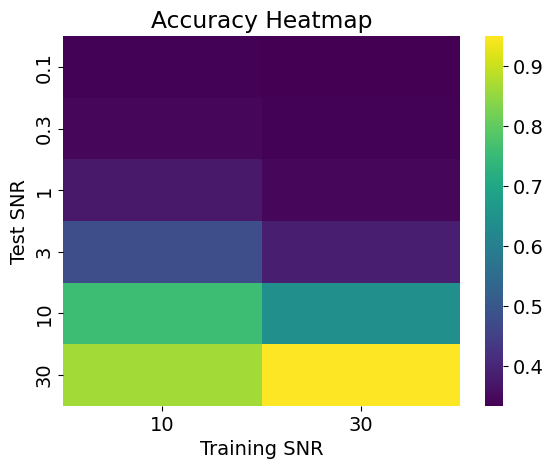

In [47]:
import pandas as pd
import seaborn as sns

tr_SNR = [10, 30]
test_SNR = [0.1, 0.3, 1, 3, 10, 30]

ACC = pd.DataFrame(ACC)

acc_r1 = pd.concat([ACC[0:5].mean(axis=0), ACC[15:20].mean(axis=0)], axis=1)
acc_r1


sns.heatmap(
    acc_r1,
    fmt=".3f",
    cmap="viridis",
    xticklabels=tr_SNR,
    yticklabels=test_SNR
)

plt.xlabel("Training SNR")
plt.ylabel("Test SNR")
plt.title("Accuracy Heatmap")
plt.show()

In [51]:
ACC

,0,1,2,3,4,5
0,0.3413,0.3399,0.3499,0.3759,0.4088,0.4790
1,0.3361,0.3485,0.3840,0.5072,0.8434,0.9571
2,0.3365,0.3474,0.3810,0.4992,0.8432,0.9675
3,0.3357,0.3465,0.3798,0.4973,0.8375,0.9645
4,0.3349,0.3476,0.3820,0.5154,0.8490,0.9563
5,0.3375,0.3453,0.3550,0.3679,0.4211,0.4842
6,0.3370,0.3504,0.3816,0.5087,0.8605,0.9572
7,0.3369,0.3478,0.3783,0.4991,0.8748,0.9653
8,0.3381,0.3487,0.3803,0.5020,0.8420,0.9566
9,0.3397,0.3524,0.3839,0.5070,0.8628,0.9606


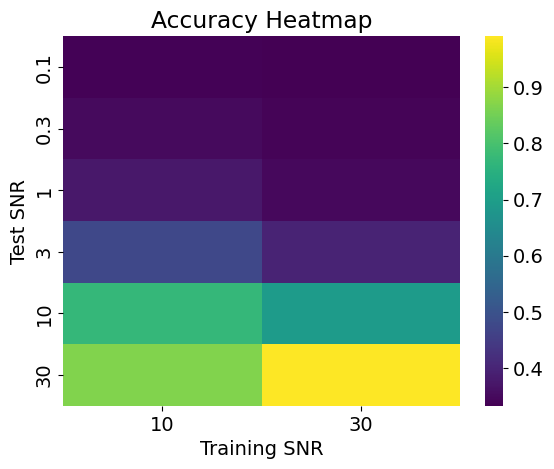

In [50]:
acc_r2 = pd.concat([ACC[5:10].mean(axis=0), ACC[20:25].mean(axis=0)], axis=1)
acc_r2


sns.heatmap(
    acc_r2,
    fmt=".3f",
    cmap="viridis",
    xticklabels=tr_SNR,
    yticklabels=test_SNR
)

plt.xlabel("Training SNR")
plt.ylabel("Test SNR")
plt.title("Accuracy Heatmap")
plt.show()

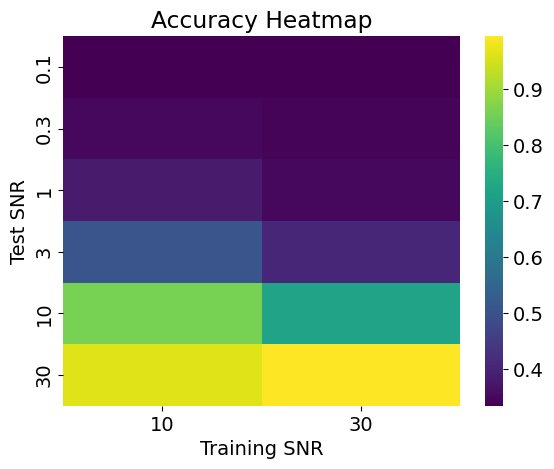

In [49]:
acc_r3 = pd.concat([ACC[10:15].mean(axis=0), ACC[25:30].mean(axis=0)], axis=1)
acc_r3


sns.heatmap(
    acc_r3,
    fmt=".3f",
    cmap="viridis",
    xticklabels=tr_SNR,
    yticklabels=test_SNR
)

plt.xlabel("Training SNR")
plt.ylabel("Test SNR")
plt.title("Accuracy Heatmap")
plt.show()